# Clustering

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Describe the three main families of clustering algorithms and the trade-offs between them
- Evaluate clustering quality using the silhouette score, Calinski-Harabász score, and Bayesian information criterion
- Implement k-means and Gaussian mixture models using scikit-learn and interpret their outputs
- Apply DBSCAN and mean shift algorithms and tune their key hyperparameters
- Build and interpret a dendrogram, and extract flat clusters using distance or count cutoffs
:::

## Clustering Overview

### Problem Statement

Clustering algorithms identify groups of data points that are similar to each other based on a set of descriptive features. Unlike classification (which is a form of supervised learning), clustering is **unsupervised**: there are no output labels. The goal is to extract insight about the inherent structure of a dataset without any ground-truth class information.

Common applications include:

- Data compression and summarization
- Group or class assignment for unlabeled data
- Searching high-dimensional feature spaces
- Identifying process operating regimes or steady states
- Outlier and anomaly detection

### Types of Clustering Algorithms

There are three main families of clustering algorithms:

**Expectation-maximization (EM)** algorithms iteratively assign points to clusters (the *expectation* step) and then refit cluster parameters to maximize a fitness criterion (the *maximization* step). This is conceptually similar to iterative generalized linear classification, but without labels. k-means and Gaussian mixture models are the canonical examples.

**Density-based** algorithms identify regions of high point density and treat low-density gaps as cluster boundaries. Cluster membership is determined by the local neighborhood, similar in spirit to k-nearest neighbors. DBSCAN and mean shift are the most widely used.

**Hierarchical** algorithms build a full connectivity tree across all points and extract clusters by applying a distance cutoff. The result can be visualized as a dendrogram. These algorithms have few hyperparameters but scale as $O(N^3)$, making them suitable for small-to-moderate datasets.

Key considerations when choosing an algorithm:

| Property | k-Means / GMM | Density-based | Hierarchical |
|---|---|---|---|
| Requires $k$ upfront | Yes | No | No |
| Handles non-convex shapes | No (k-means) / Partial (GMM) | Yes | Depends on linkage |
| Identifies noise/outliers | No | Yes (DBSCAN) | No |
| Mixed membership | No (k-means) / Yes (GMM) | No | No |
| Scales to large $N$ | Yes | Moderate | No ($O(N^3)$) |

:::{exercise}
:label: ex-eda-cluster-compare

For each scenario below, identify the most appropriate clustering algorithm family (EM, density-based, or hierarchical) and briefly justify your choice: (a) You have 50,000 process sensor readings and expect 4 distinct operating regimes. (b) You have 200 samples from a chemical reaction trajectory and want to visualize how reaction states relate to each other. (c) Your dataset has irregularly shaped clusters and you want noise points explicitly flagged.
:::

## Accuracy and Distance Metrics

Evaluating unsupervised models is challenging because there is no ground truth. Several metrics have been developed based on the geometry of the resulting clusters.

**Silhouette score** is defined for each point:
- $a$ — average distance from a point to all other points in its cluster
- $b$ — average distance from a point to all points in the nearest neighboring cluster
- $S = \frac{b - a}{\max(a, b)}$, where $S = 1$ is best and $S = -1$ is worst

The average silhouette score over all points provides an overall quality measure. It works well for compact, well-separated clusters but is less reliable for density-based clusters (e.g., DBSCAN).

**Calinski-Harabász score** (variance ratio criterion) is related to the ratio of between-cluster variance to within-cluster variance. Higher values indicate denser and better-separated clusters. It is not bounded, which makes absolute interpretation difficult.

**Bayesian information criterion (BIC)** applies to models with an underlying probability distribution (such as GMMs). It trades off model fit (log-likelihood) against model complexity (number of parameters). Lower BIC indicates a better model.

**Classification metrics** (confusion matrix, precision, recall) can be applied when true labels are available — but not directly, because cluster numbers are arbitrary. There is no reason a clustering's cluster 2 should be your class 2, so accuracy computed against raw cluster labels is meaningless: a perfect clustering can score zero simply because the numbering does not line up.

**Purity** is the standard repair. Each cluster takes the class most common within it, and the score is the fraction of points that gets right. With clusters $\Omega = \{\omega_1, \dots, \omega_K\}$ and classes $C = \{c_1, \dots, c_J\}$,

$$
\text{purity}(\Omega, C) \;=\; \frac{1}{N} \sum_{k=1}^{K} \max_{j} \; |\omega_k \cap c_j|
$$

On a confusion matrix with classes as rows and clusters as columns, that is the sum of the **column maxima** over $N$. Taking maxima down columns rather than across rows is what makes purity independent of the numbering: relabeling permutes the columns, and a sum ignores their order.

Purity runs from about $1/J$ for an uninformative clustering (balanced classes) to $1$ for a perfect one. Its weakness is that it **increases monotonically with $K$** — splitting a cluster can never lower a majority vote, and one point per cluster gives purity $1$ while saying nothing. So purity reports on a clustering whose $K$ was chosen some other way; it cannot choose $K$, and purities at different $K$ are not comparable. Normalized mutual information and the adjusted Rand index correct for this, and both are in `sklearn.metrics`.

All clustering algorithms depend on a **distance metric**. Common choices:

| Metric | Formula |
|---|---|
| Euclidean ($L_2$) | $D_{ij} = \sqrt{\sum (x_i - x_j)^2}$ |
| Manhattan ($L_1$) | $D_{ij} = \sum \|x_i - x_j\|$ |
| Chebyshev ($L_\infty$) | $D_{ij} = \max \|x_i - x_j\|$ |
| Mahalanobis | $D_{ij} = (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{C}^{-1} (\mathbf{x}_j - \boldsymbol{\mu})$ |

The Mahalanobis distance implicitly standardizes using the covariance matrix $\mathbf{C}$, making it scale-invariant. In scikit-learn, the metric is typically controlled by a `metric=` keyword argument.

:::{exercise}
:label: ex-eda-silhouette-calc

Point $p$ has within-cluster average distance $a = 0.4$ and average distance to the nearest other cluster $b = 1.2$. (a) Compute the silhouette score for $p$. (b) If $b$ were reduced to $0.5$ (clusters move closer together), recompute the silhouette score and explain what this change implies about cluster quality.
:::

:::{exercise}
:label: ex-eda-purity-calc

A clustering of $N = 100$ points into $K = 3$ clusters is compared against $J = 3$ true classes, giving the confusion matrix below (rows are true classes, columns are clusters):

| | $\omega_1$ | $\omega_2$ | $\omega_3$ |
|---|---|---|---|
| $c_1$ | 30 | 4 | 1 |
| $c_2$ | 5 | 22 | 8 |
| $c_3$ | 3 | 7 | 20 |

(a) Compute the purity. (b) Now suppose $\omega_2$ is split into two clusters of 16 and 17 points, whose majority classes contribute 14 and 11 correct points respectively. Recompute the purity and state whether the clustering has actually improved. (c) What purity would you get by placing each of the 100 points in its own cluster, and what does that tell you about using purity to select $K$?
:::

## Dataset Preparation

In this chapter we work with the Dow chemical process dataset. Clustering algorithms operate in any dimension, but intuition is much easier to build in 2D. A common EDA strategy is therefore to apply dimensionality reduction first, cluster on the low-dimensional representation to build intuition, and then verify whether the same structure holds in the full feature space.

The following code blocks load and standardize the Dow dataset (the same cleaning steps used in earlier chapters), then subsample it to keep the clustering demonstrations fast.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('../settings/plot_style.mplstyle')
clrs = np.array([p['color'] for p in plt.rcParams['axes.prop_cycle']])

In [2]:
df = pd.read_excel('data/impurity_dataset-training.xlsx')

def is_real_and_finite(x):
    try:
        return bool(np.isreal(x) and np.isfinite(x))
    except (TypeError, ValueError):
        return False

all_data    = df[df.columns[1:]].values
numeric_map = df[df.columns[1:]].apply(lambda col: col.map(is_real_and_finite))
real_rows   = numeric_map.all(axis=1).values

X_dow = np.array(all_data[real_rows, :-5], dtype='float')
y_dow = np.array(all_data[real_rows, -3],  dtype='float').reshape(-1, 1)
print(f'X_dow: {X_dow.shape},  y_dow: {y_dow.shape}')

X_dow: (10297, 40),  y_dow: (10297, 1)


In [3]:
# Standardize and subsample to speed up clustering demonstrations
X = (X_dow - X_dow.mean(axis=0)) / X_dow.std(axis=0)
X = X[::5]
print(f'Working dataset: {X.shape}')

Working dataset: (2060, 40)


Here we apply three different dimensionality reduction options — linear PCA, kernel PCA, and t-SNE — so we can see how the choice of embedding affects the clusters that each algorithm subsequently finds.

In [4]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

n_components = 2

pca    = PCA(n_components=n_components)
X_pca  = pca.fit_transform(X)

kpca   = KernelPCA(n_components=n_components, kernel='rbf', gamma=0.1)
X_kpca = kpca.fit_transform(X)

tsne   = TSNE(n_components=n_components, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)

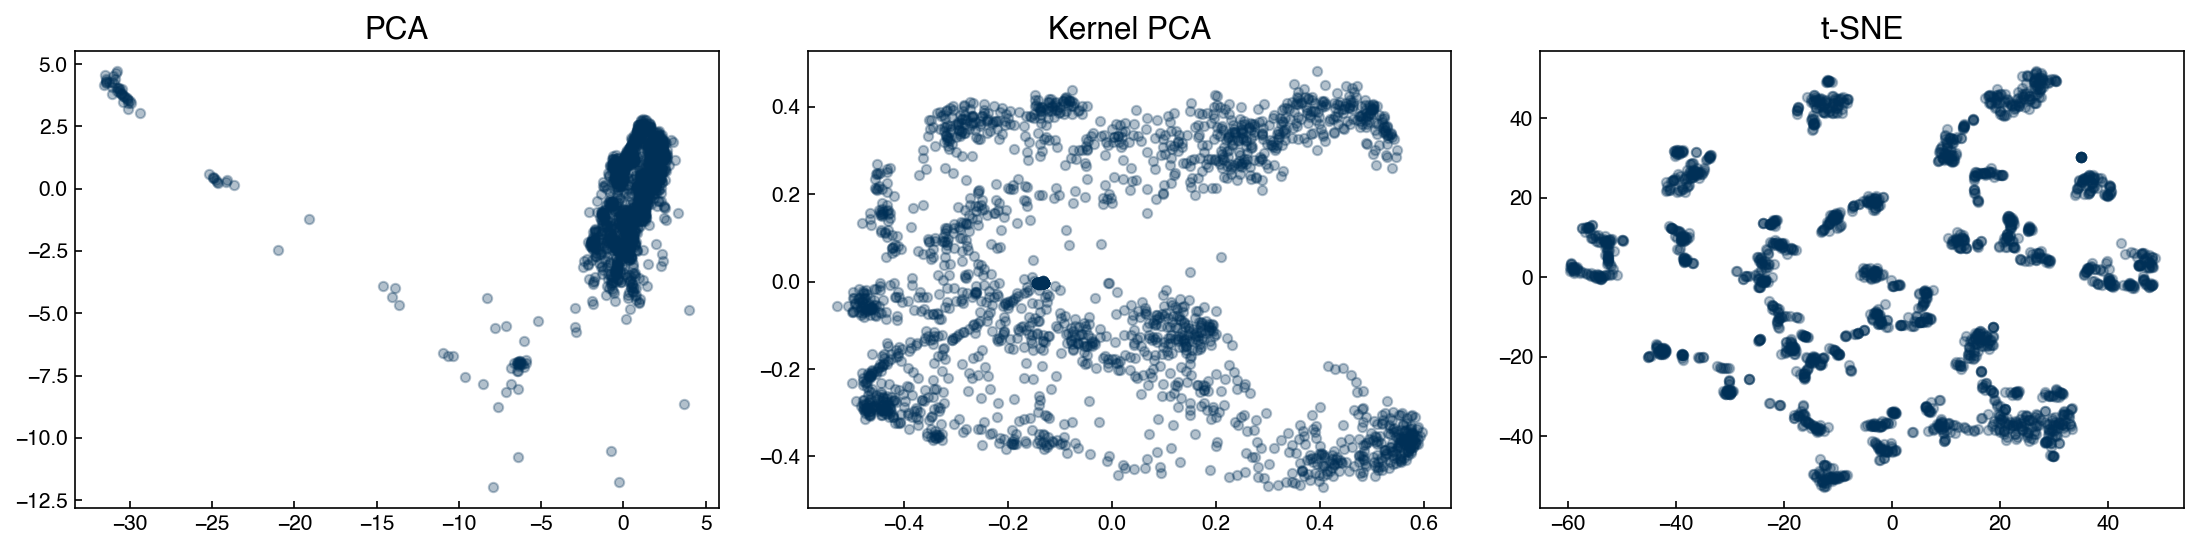

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for X_i, label, ax in zip([X_pca, X_kpca, X_tsne],
                           ['PCA', 'Kernel PCA', 't-SNE'], axes):
    ax.scatter(X_i[:, 0], X_i[:, 1], alpha=0.3, s=20)
    ax.set_title(label)
plt.tight_layout()

The structure of the low-dimensional representations differs markedly across techniques. Throughout this chapter we use all three embeddings to illustrate how the same clustering algorithm can yield different groupings depending on how the data were reduced.

:::{exercise}
:label: ex-eda-cluster-prep

Re-run the dimensionality reduction above but use `n_components=3` instead of 2. Then create a 3D scatter plot of the PCA result using `ax = fig.add_subplot(projection='3d')` and `ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], alpha=0.3, s=10)`. Does the third principal component reveal additional structure that is not visible in the 2D projection?
:::

## Expectation-Maximization Models

### k-Means

The k-means algorithm is the simplest and most widely used clustering method. It works best when:
- The number of clusters is known in advance
- Clusters are roughly spherical with similar sizes
- Cluster boundaries are approximately linear

The algorithm uses **expectation-maximization** in two alternating steps:
1. **Expectation**: assign each point to the nearest centroid
2. **Maximization**: move each centroid to the mean of its assigned points

These steps are repeated until the centroids no longer move.

:::{figure} images/kmeans_animation.gif
:name: fig-kmeans-anim
:width: 55%

k-means on three well-separated synthetic clusters. All three centroids are deliberately initialized inside a single blob; over a few iterations the expectation and maximization steps pull them apart until each settles on its own cluster.
:::

To make the mechanics concrete, here is a minimal implementation applied to the PCA-reduced Dow dataset:

In [6]:
def dist(pt1, pt2):
    return np.sqrt(np.sum((np.array(pt1) - np.array(pt2))**2))

def expected_assignment(pt, centers):
    dists = [dist(pt, c) for c in centers]
    return dists.index(min(dists))

def update_centers(clusters, centers):
    centers = list(centers)
    for i, pts in enumerate(clusters):
        if pts:
            centers[i] = np.mean(pts, axis=0)
    return centers

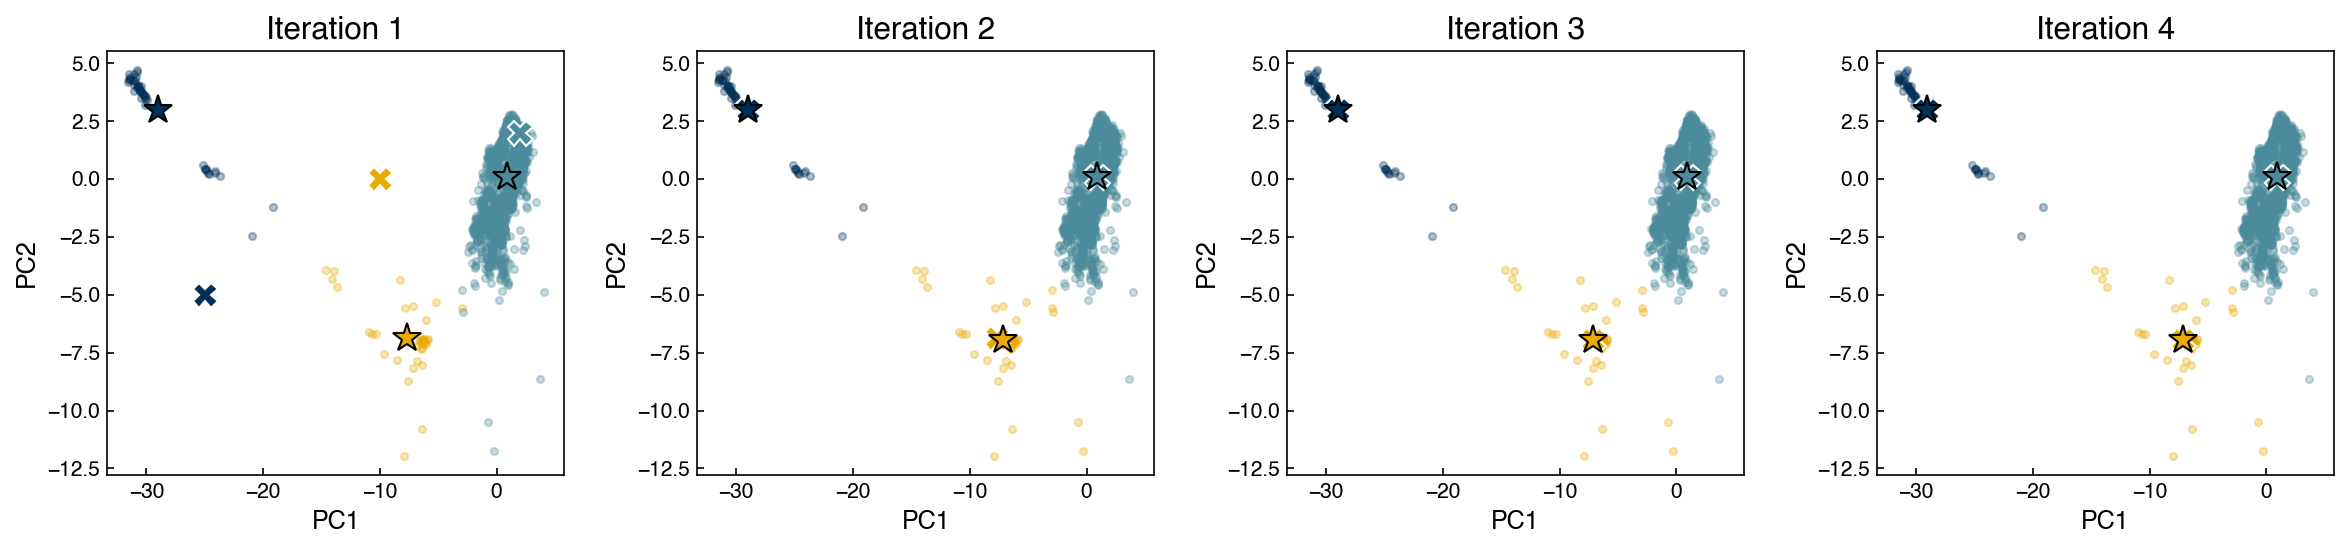

In [7]:
# Show four iterations of k-means from a deliberately poor initial guess
X_km    = X_pca
centers = [np.array(c, dtype=float) for c in ([-25, -5], [-10, 0], [2, 2])]
n_k     = len(centers)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for step, ax in enumerate(axes):
    old_centers = [c.copy() for c in centers]
    clusters    = [[] for _ in range(n_k)]
    for pt in X_km:
        clusters[expected_assignment(pt, centers)].append(pt)
    centers = update_centers(clusters, centers)
    for i, pts in enumerate(clusters):
        if pts:
            pts_arr = np.array(pts)
            ax.scatter(pts_arr[:, 0], pts_arr[:, 1],
                       color=clrs[i], alpha=0.3, s=12)
    for i, (old, new) in enumerate(zip(old_centers, centers)):
        ax.plot(*old, marker='X', ms=12, color=clrs[i], mec='w')
        ax.plot(*new, marker='*', ms=14, color=clrs[i], mec='k')
    ax.set_title(f'Iteration {step + 1}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

The X markers show old centroid positions; stars show updated positions. Even though all three centroids start clustered on the left side of the data, they redistribute over the first few iterations until each one settles into a distinct region — including the small isolated group near the right, which becomes its own cluster.

In practice, use the scikit-learn implementation, which is substantially faster and more robust:

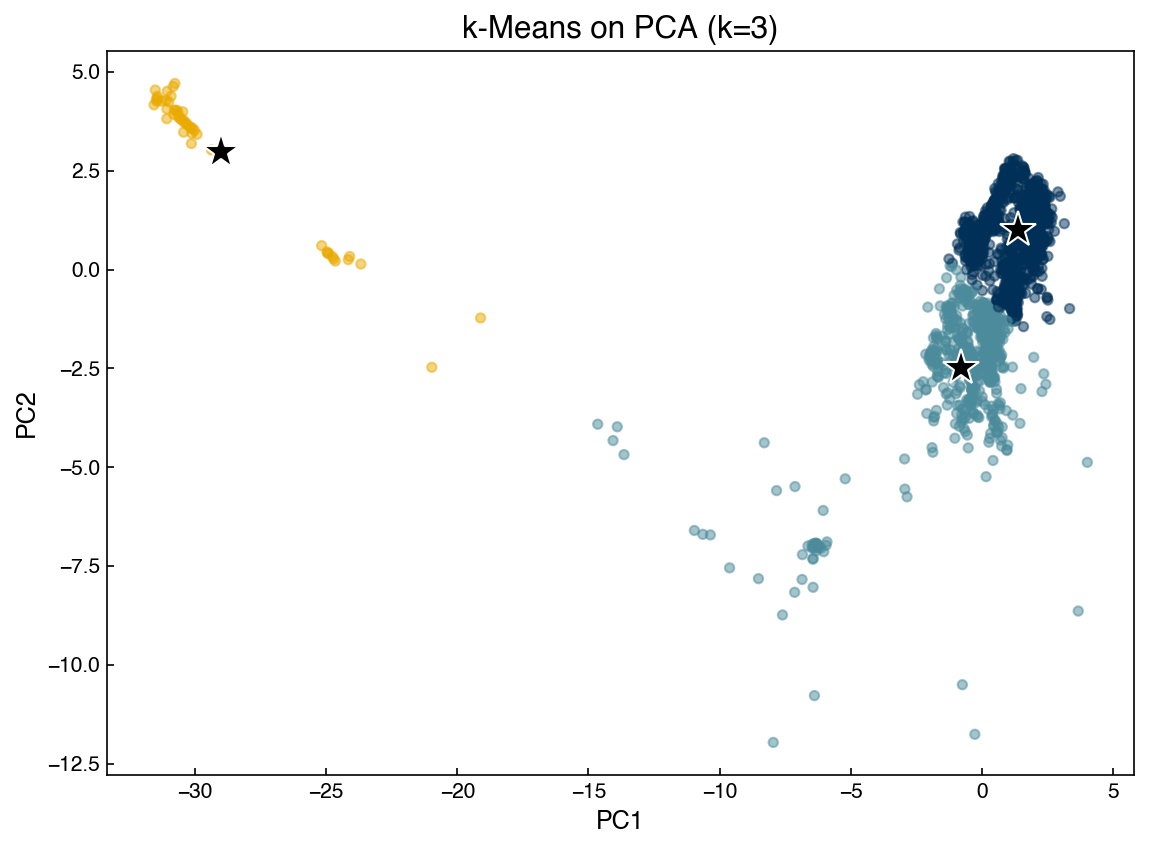

In [8]:
from sklearn.cluster import KMeans

model  = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = model.fit_predict(X_pca)

fig, ax = plt.subplots()
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clrs[y_pred % len(clrs)], alpha=0.5, s=20)
for cx, cy in model.cluster_centers_:
    ax.plot(cx, cy, marker='*', color='k', mec='w', markersize=18)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('k-Means on PCA (k=3)')
plt.tight_layout()

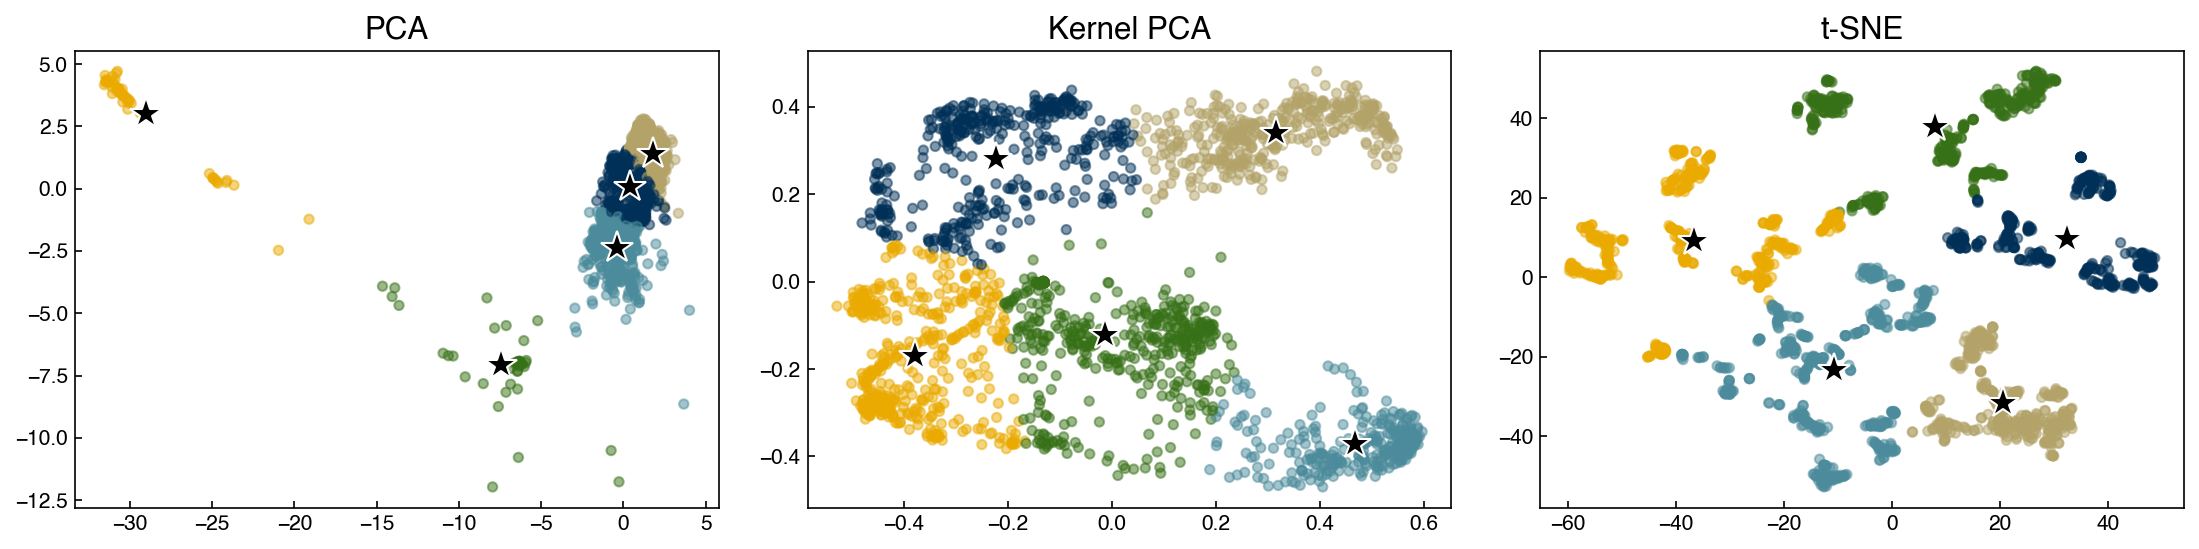

In [9]:
# Apply k-means across all three embeddings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for X_i, label, ax in zip([X_pca, X_kpca, X_tsne],
                           ['PCA', 'Kernel PCA', 't-SNE'], axes):
    model  = KMeans(n_clusters=5, random_state=0, n_init=10)
    y_pred = model.fit_predict(X_i)
    ax.scatter(X_i[:, 0], X_i[:, 1], c=clrs[y_pred % len(clrs)], alpha=0.5, s=20)
    for center in model.cluster_centers_:
        ax.plot(*center, marker='*', color='k', mec='w', markersize=16)
    ax.set_title(label)
plt.tight_layout()

:::{note}
The geometrically isolated cluster visible in the PCA scatter may represent an outlier operating regime. k-means assigns every point to a cluster and never flags outliers explicitly — if outlier detection is the goal, a density-based method is more appropriate.
:::

**Demonstration: k-means with a convergence criterion**

The animation above ran a fixed number of iterations, but in practice we do not know in advance how many are needed. The standard solution is a **tolerance-based stopping criterion**: stop as soon as the centroids move less than some small distance `tol` in an iteration, which signals that the algorithm has effectively converged. The implementation below adds exactly this check (and reports how many iterations it took), starting from the same poor initial guess as before:

Converged after 3 iterations (delta=0.0000)


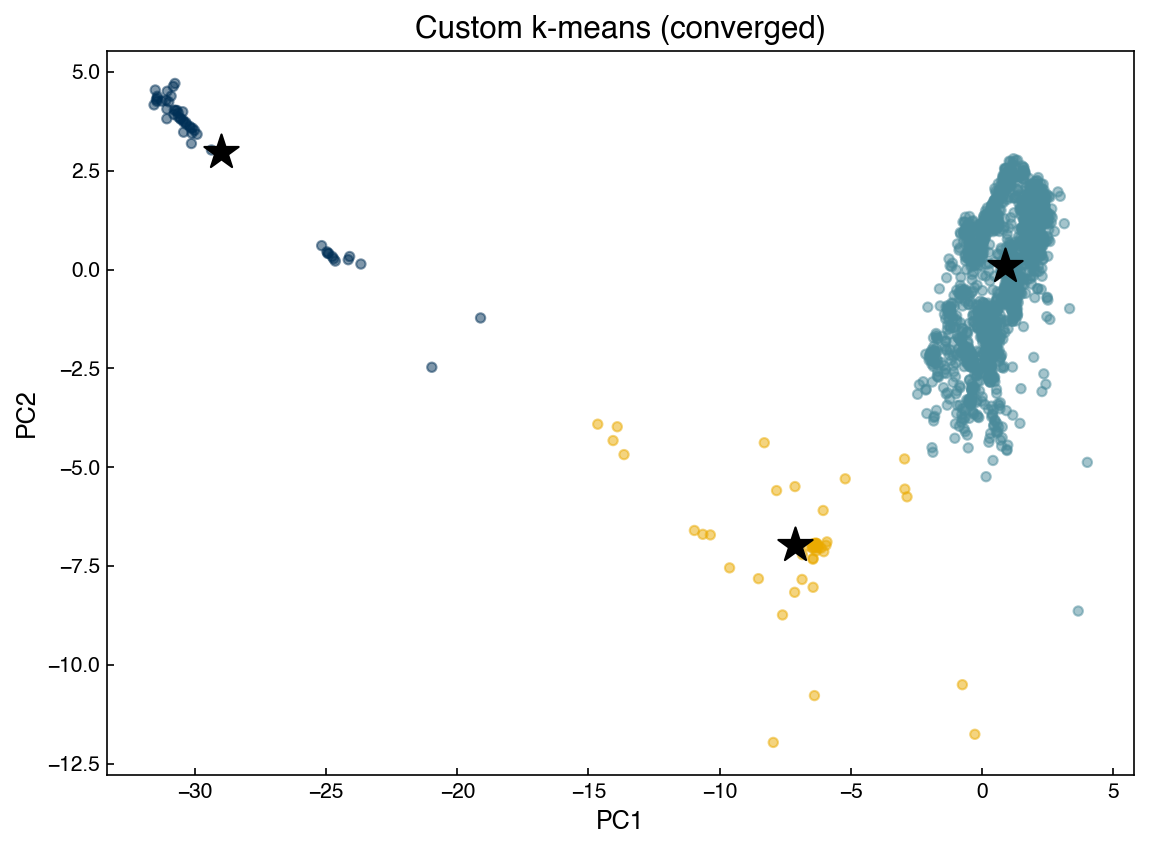

In [10]:
def kmeans(X, initial_centers, tol=0.01, max_iter=100):
    centers = [np.array(c, dtype=float) for c in initial_centers]
    n_k     = len(centers)
    for iteration in range(max_iter):
        old_centers = [c.copy() for c in centers]
        clusters    = [[] for _ in range(n_k)]
        for pt in X:
            clusters[expected_assignment(pt, centers)].append(pt)
        centers = update_centers(clusters, centers)
        delta   = max(dist(o, n) for o, n in zip(old_centers, centers))
        if delta < tol:
            print(f'Converged after {iteration + 1} iterations (delta={delta:.4f})')
            break
    labels = [expected_assignment(pt, centers) for pt in X]
    return np.array(labels), np.array(centers)

labels_custom, centers_custom = kmeans(
    X_pca, initial_centers=([-25, -5], [-10, 0], [2, 2]))

fig, ax = plt.subplots()
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c=clrs[labels_custom % len(clrs)], alpha=0.5, s=20)
ax.scatter(centers_custom[:, 0], centers_custom[:, 1],
           marker='*', s=300, color='k', zorder=5)
ax.set_title('Custom k-means (converged)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

:::{exercise}
:label: ex-eda-kmeans-elbow

The **elbow method** selects the number of clusters by plotting within-cluster inertia (`model.inertia_` after fitting `KMeans`) against $k$ and identifying the point where adding more clusters yields diminishing returns. Using the PCA-reduced Dow dataset, plot both inertia and silhouette score for $k \in [2, 12]$. Do the two criteria suggest the same optimal $k$?
:::

### Gaussian Mixture Models

Gaussian mixture models (GMMs) extend k-means by modeling each cluster as a multivariate Gaussian. The full distribution is:

$$P(\mathbf{x}) = \sum_k \phi_k \,\mathcal{N}(\mathbf{x};\, \boldsymbol{\mu}_k,\, \boldsymbol{\Sigma}_k)$$

where $\phi_k$ are mixture weights ($\sum_k \phi_k = 1$), $\boldsymbol{\mu}_k$ is the cluster mean, and $\boldsymbol{\Sigma}_k$ is the covariance matrix.

:::{figure} images/gmm_em_animation.gif
:name: fig-gmm-em
:width: 60%

Illustration of the GMM expectation-maximization algorithm. Ellipses show the current Gaussian components; points are colored by their most probable cluster assignment. Over iterations the components shift to better describe the data.
:::

GMMs are fit with the same expectation-maximization loop as k-means, but expressed in terms of probabilities. Two statistical terms recur. The **posterior probability** $\gamma_{ik}$ is the probability that point $i$ belongs to cluster $k$ *given* the current model — computed with Bayes' rule from the mixture weights and the Gaussian densities. **Maximum likelihood** estimation chooses the parameters (means, covariances, weights) that make the observed data most probable under the model. The two steps alternate: estimate the posteriors with the current parameters, then update the parameters to maximize the likelihood given those posteriors.

**Expectation step** — compute the posterior probability that point $i$ belongs to cluster $k$:

$$\gamma_{ik} = \frac{\phi_k \,\mathcal{N}(\mathbf{x}_i;\,\boldsymbol{\mu}_k,\,\boldsymbol{\Sigma}_k)}{\sum_j \phi_j \,\mathcal{N}(\mathbf{x}_i;\,\boldsymbol{\mu}_j,\,\boldsymbol{\Sigma}_j)}$$

**Maximization step** — update parameters by maximum likelihood:

$$\phi_k = \frac{1}{N}\sum_i \gamma_{ik}, \qquad
\boldsymbol{\mu}_k = \frac{\sum_i \gamma_{ik}\mathbf{x}_i}{\sum_i \gamma_{ik}}, \qquad
\boldsymbol{\Sigma}_k = \frac{\sum_i \gamma_{ik}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{\sum_i \gamma_{ik}}$$

GMMs are more flexible than k-means because clusters can have different shapes via the covariance matrix. The `covariance_type` hyperparameter controls this flexibility:

| `covariance_type` | Meaning |
|---|---|
| `'full'` | Each cluster has its own full covariance matrix |
| `'tied'` | All clusters share a single covariance matrix |
| `'diag'` | Each cluster has an axis-aligned ellipsoid |
| `'spherical'` | Each cluster has one scalar variance (similar to k-means) |

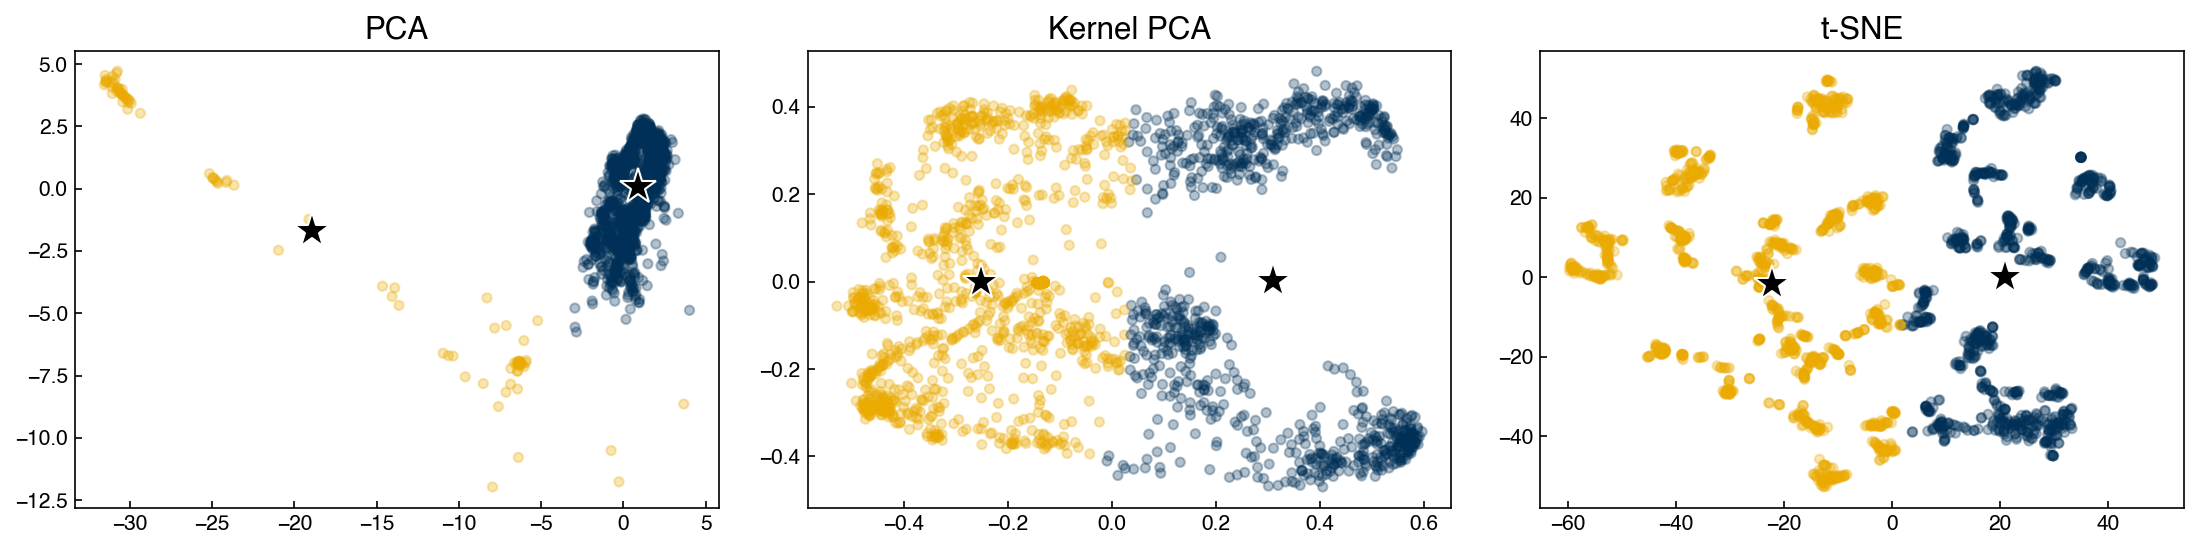

In [11]:
from sklearn.mixture import GaussianMixture

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for X_i, label, ax in zip([X_pca, X_kpca, X_tsne],
                           ['PCA', 'Kernel PCA', 't-SNE'], axes):
    model  = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
    model.fit(X_i)
    y_pred = model.predict(X_i)
    ax.scatter(X_i[:, 0], X_i[:, 1], c=clrs[y_pred], alpha=0.3, s=20)
    for cx, cy in model.means_:
        ax.plot(cx, cy, marker='*', color='k', mec='w', markersize=18)
    ax.set_title(label)
plt.tight_layout()

A key advantage of GMMs over k-means is **mixed membership**: each point is assigned a full probability vector across clusters. The predicted label is simply the cluster with the highest probability, but we can inspect ambiguous points by checking whether that probability is close to 1.

**Demonstration: silhouette score and BIC as a function of number of clusters**

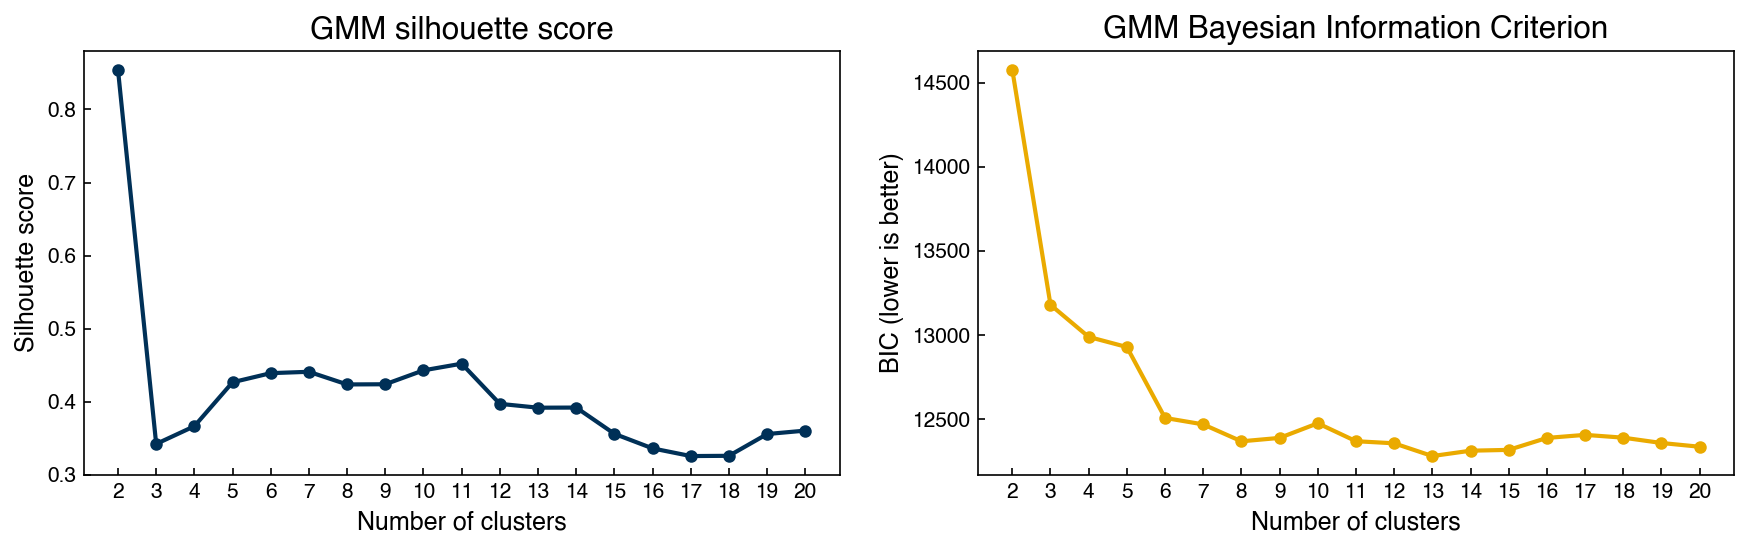

In [12]:
from sklearn.metrics import silhouette_score

n_clusters_list = np.arange(2, 21)
silhouette_list = []
bic_list        = []

for n in n_clusters_list:
    m      = GaussianMixture(n_components=n, random_state=0)
    m.fit(X_pca)
    y_pred = m.predict(X_pca)
    silhouette_list.append(silhouette_score(X_pca, y_pred))
    bic_list.append(m.bic(X_pca))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_clusters_list, silhouette_list, '-o', ms=5)
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('GMM silhouette score')
axes[0].set_xticks(n_clusters_list)

axes[1].plot(n_clusters_list, bic_list, '-o', ms=5, color=clrs[1])
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('BIC (lower is better)')
axes[1].set_title('GMM Bayesian Information Criterion')
axes[1].set_xticks(n_clusters_list)
plt.tight_layout()

Unlike the silhouette score, BIC explicitly penalizes model complexity by adding a term proportional to the number of parameters. In textbook cases with a few clean Gaussian clusters this keeps BIC from selecting too many components. On this dataset, however, BIC keeps decreasing well past a handful of components and only bottoms out around a dozen — because the Dow process data is not actually a small number of tidy Gaussians. Each extra component improves the likelihood more than the complexity penalty costs, so BIC is effectively using many Gaussians to approximate a continuous density rather than identifying a few "true" clusters. This is a useful reminder that these criteria answer "which model fits best," not "how many real groups are there" — the two questions only coincide when the data really is clustered. The silhouette score, which rewards compact well-separated groups, often prefers far fewer clusters; using both in tandem gives a more balanced picture.

**Demonstration: filtering to well-defined cluster members**

This demonstration puts the GMM's mixed-membership probabilities to practical use. Because each point carries a full probability vector across clusters (not just a hard label), we can keep only the points the model is confident about — those whose highest cluster probability exceeds 0.95 — and discard ambiguous boundary points. This is a common way to extract a "clean core" of each operating regime before further analysis:

Silhouette (all):          0.443
Silhouette (well-defined): 0.638


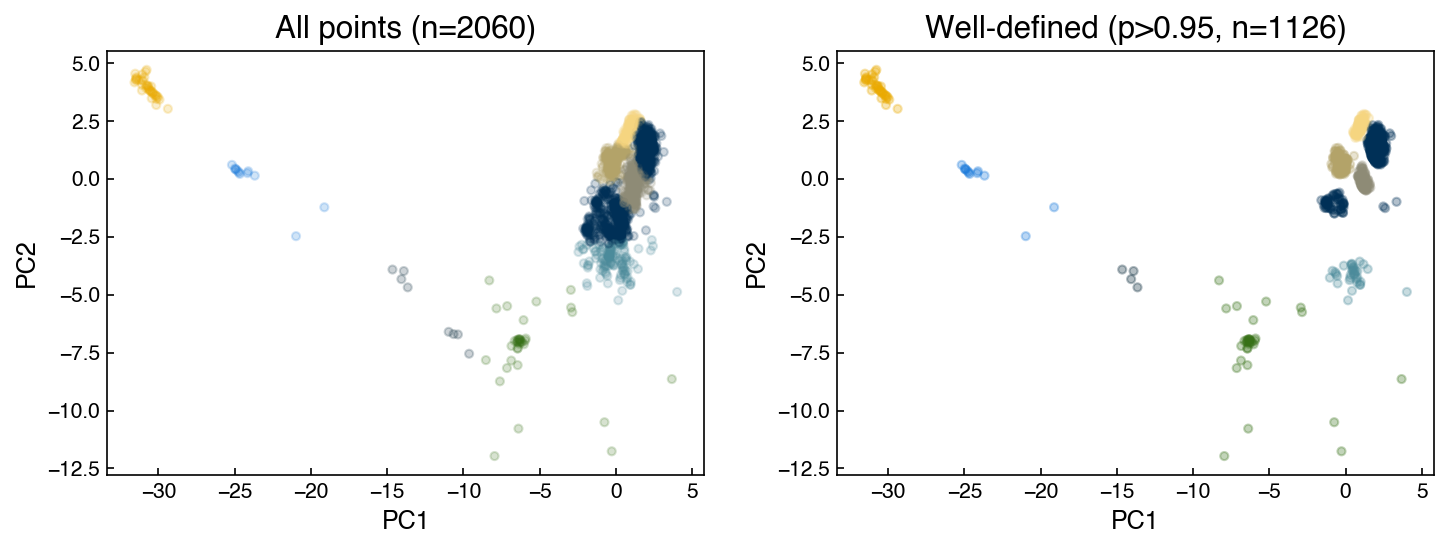

In [13]:
model  = GaussianMixture(n_components=10, covariance_type='full', random_state=0)
model.fit(X_pca)
y_pred = model.predict(X_pca)
probs  = model.predict_proba(X_pca)

mask          = probs.max(axis=1) > 0.95
X_welldefined = X_pca[mask]
y_welldefined = y_pred[mask]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=clrs[y_pred % len(clrs)], alpha=0.2, s=15)
axes[0].set_title(f'All points (n={len(X_pca)})')
axes[1].scatter(X_welldefined[:, 0], X_welldefined[:, 1],
                c=clrs[y_welldefined % len(clrs)], alpha=0.3, s=15)
axes[1].set_title(f'Well-defined (p>0.95, n={mask.sum()})')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
print(f'Silhouette (all):          {silhouette_score(X_pca, y_pred):.3f}')
print(f'Silhouette (well-defined): {silhouette_score(X_welldefined, y_welldefined):.3f}')
plt.tight_layout()

Restricting to high-confidence assignments substantially improves the silhouette score, confirming that ambiguous boundary points are responsible for much of the cluster overlap.

:::{exercise}
:label: ex-eda-gmm-bic

Using the BIC curve above as a guide, identify the optimal number of GMM components for the PCA-reduced Dow dataset. Refit a GMM with that number of components and plot the cluster assignments. Then refit a k-means model with the same $k$ and compare silhouette scores for the two methods. Which better separates the data, and why might that be?
:::

## Density-Based Models

Density-based algorithms group points according to local data density. They do not require the number of clusters to be specified in advance and can naturally identify noise or outlier points.

### Mean Shift

The mean shift algorithm finds cluster centers by iteratively moving each candidate centroid toward the mean of the points within a local window of radius $r$ (the **bandwidth**). The update rule for centroid $\mathbf{c}$:

$$\mathbf{c}^{(t+1)} = \frac{\sum_{i : \|\mathbf{x}_i - \mathbf{c}^{(t)}\| \leq r} \mathbf{x}_i}{\left|\{i : \|\mathbf{x}_i - \mathbf{c}^{(t)}\| \leq r\}\right|}$$

A key insight is that every data point can serve as an initial centroid. After convergence, nearby centroids are merged, and the resulting unique centroids define the clusters.

:::{figure} images/meanshift_animation.gif
:name: fig-meanshift-anim
:width: 55%

Mean shift on three synthetic clusters. Many candidate centroids (gold) each climb toward the nearest peak of point density; centroids that converge to the same location merge, so the number of clusters emerges from the bandwidth rather than being specified in advance.
:::

In [14]:
def get_new_centroid(centroid, x_list, r):
    nearby = [xi for xi in x_list if np.linalg.norm(centroid - xi) <= r]
    return np.mean(nearby, axis=0) if nearby else centroid

def mean_shift_clustering(x_list, r, tol=0.01):
    centroids = np.array(x_list, dtype=float)
    delta = np.inf
    while delta >= tol:
        new_centroids = np.array([get_new_centroid(c, centroids, r)
                                  for c in centroids])
        delta     = np.linalg.norm(centroids - new_centroids)
        centroids = new_centroids
    # Merge centroids within tolerance of each other
    unique = []
    for c in centroids:
        if not any(np.linalg.norm(c - u) <= tol for u in unique):
            unique.append(c)
    labels = [min(range(len(unique)),
                  key=lambda j: np.linalg.norm(pt - unique[j]))
              for pt in x_list]
    return np.array(labels), np.array(unique)

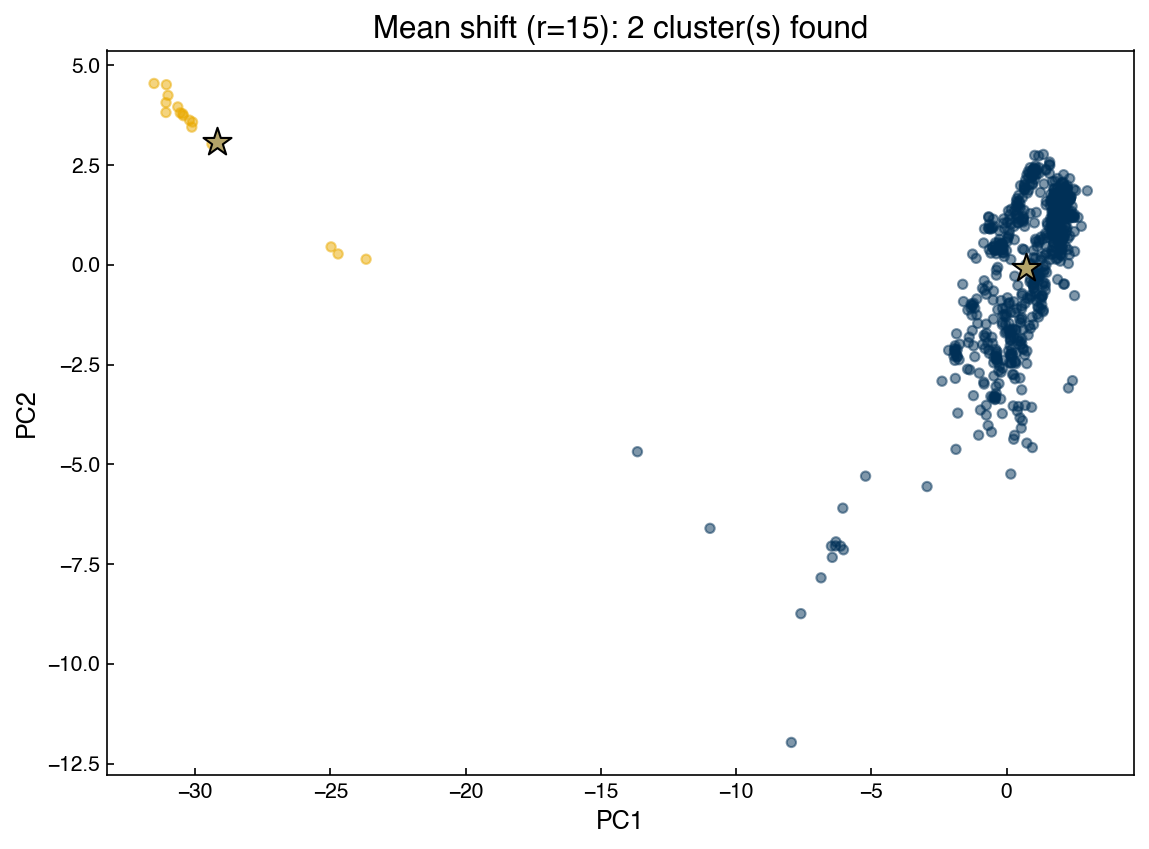

In [15]:
X_ms = X_pca[::3]   # subsample for speed
r    = 15
labels_ms, centroids_ms = mean_shift_clustering(X_ms, r)

fig, ax = plt.subplots()
ax.scatter(X_ms[:, 0], X_ms[:, 1],
           c=clrs[labels_ms % len(clrs)], alpha=0.5, s=20)
ax.scatter(centroids_ms[:, 0], centroids_ms[:, 1],
           marker='*', s=200, color=clrs[3], edgecolors='k', zorder=5)
ax.set_title(f'Mean shift (r={r}): {len(centroids_ms)} cluster(s) found')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

:::{note}
If a centroid's initial position is very far from any data point (e.g., `[10000, 0]`), the local window will contain no points and the centroid will not move — it becomes orphaned. This is why using every data point as an initial centroid is the standard strategy: it guarantees that no region of actual data density is missed. The bandwidth controls the granularity: larger bandwidth → fewer, larger clusters; smaller bandwidth → more, smaller clusters.
:::

The scikit-learn implementation is substantially faster and applies a seeding strategy to reduce the number of initial centroids:

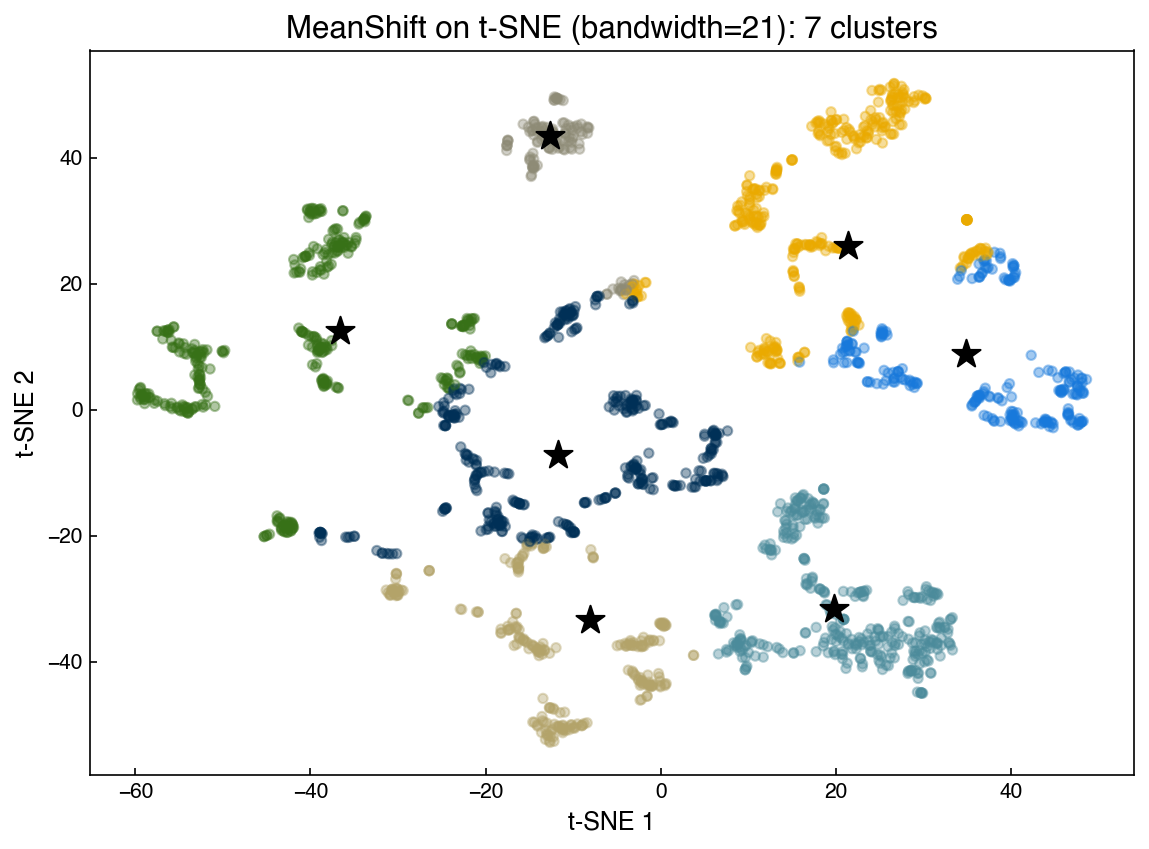

In [16]:
from sklearn.cluster import MeanShift

model_ms     = MeanShift(bandwidth=21)
model_ms.fit(X_tsne)
labels_sk    = model_ms.labels_
centroids_sk = model_ms.cluster_centers_

fig, ax = plt.subplots()
ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
           c=clrs[labels_sk % len(clrs)], alpha=0.4, s=20)
ax.scatter(centroids_sk[:, 0], centroids_sk[:, 1],
           marker='*', s=200, color='k', zorder=5)
ax.set_title(f'MeanShift on t-SNE (bandwidth=21): {len(centroids_sk)} clusters')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()

**Demonstration: silhouette score vs. bandwidth**

The bandwidth is mean shift's single most important hyperparameter, and unlike k-means there is no $k$ to set — the number of clusters is an *output* that depends on the bandwidth. This demonstration sweeps a range of bandwidths and tracks two things at once: how many clusters mean shift finds, and how good those clusters are (silhouette score). Together they show the trade-off — too small a bandwidth fragments the data into many clusters, too large a bandwidth merges everything into one:

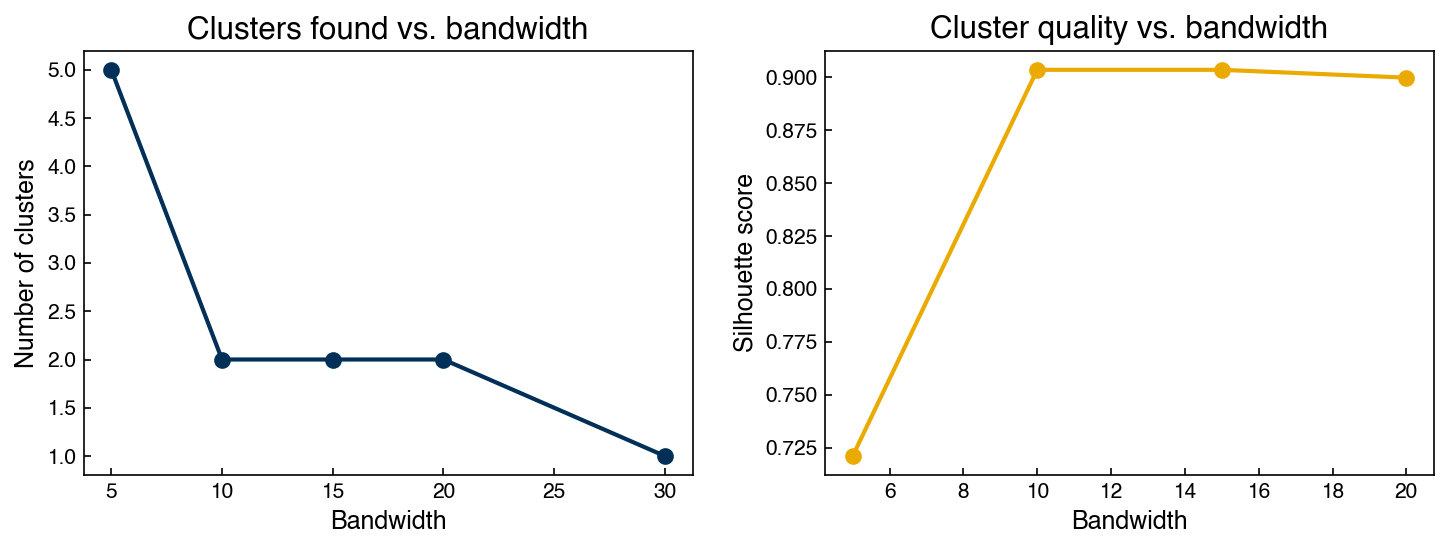

In [17]:
bandwidths = [5, 10, 15, 20, 30]
n_found    = []
scores     = []

for bw in bandwidths:
    m = MeanShift(bandwidth=bw)
    m.fit(X_pca)
    n_found.append(len(m.cluster_centers_))
    if len(set(m.labels_)) > 1:
        scores.append(silhouette_score(X_pca, m.labels_))
    else:
        scores.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(bandwidths, n_found, '-o', ms=7)
axes[0].set_xlabel('Bandwidth'); axes[0].set_ylabel('Number of clusters')
axes[0].set_title('Clusters found vs. bandwidth')
axes[1].plot(bandwidths, scores, '-o', ms=7, color=clrs[1])
axes[1].set_xlabel('Bandwidth'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Cluster quality vs. bandwidth')
plt.tight_layout()

:::{exercise}
:label: ex-eda-meanshift-bw

Extend the bandwidth sweep above to include `bandwidth=3` and `bandwidth=50`. For each bandwidth, also report the Calinski-Harabász score (`calinski_harabasz_score` from `sklearn.metrics`). Does the Calinski-Harabász score agree with the silhouette score on the best bandwidth?
:::

### DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) defines clusters as dense regions of points connected through short-range neighborhoods. Unlike mean shift, DBSCAN can find clusters of arbitrary shape and explicitly marks low-density points as noise (label $-1$).

:::{figure} images/dbscan_animation.gif
:name: fig-dbscan-anim
:width: 60%

Illustration of the DBSCAN algorithm. Core points (within a dense neighborhood) are shown in color; border points lie on the edge of a cluster; noise points remain gray.
:::

The algorithm:
1. Select a random unlabeled point; find all neighbors within distance $\varepsilon$.
2. If fewer than `min_samples` neighbors exist, label the point as noise. Otherwise, start a new cluster.
3. Recursively expand the cluster to all density-reachable points.
4. Repeat until all points are labeled.

Key hyperparameters:
- $\varepsilon$ (`eps`): neighborhood radius — controls cluster granularity
- `min_samples`: minimum neighbors to define a core point — controls noise sensitivity

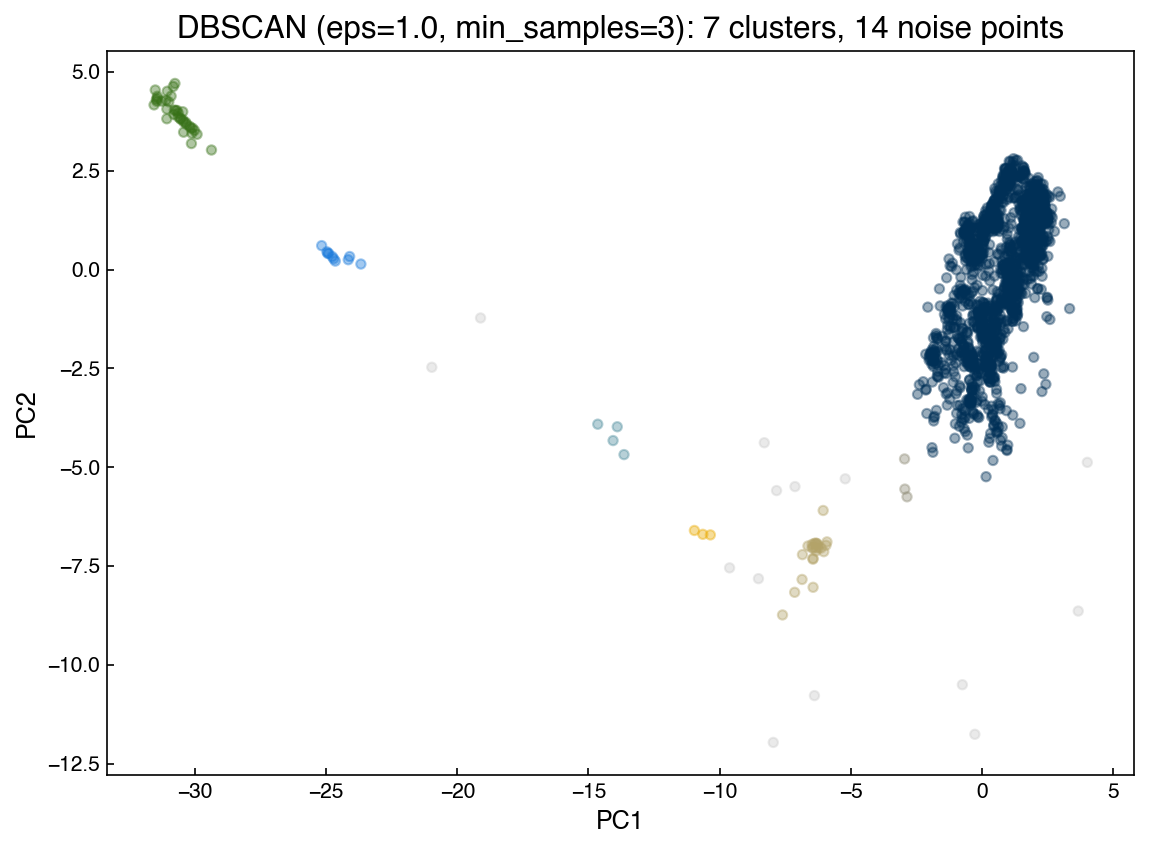

In [18]:
from sklearn.cluster import DBSCAN

model_db      = DBSCAN(eps=1.0, min_samples=3)
y_db          = model_db.fit_predict(X_pca)
n_clusters_db = len(set(y_db)) - (1 if -1 in y_db else 0)

# Noise points (label -1) shown in gray; cluster points colored by palette
colors = np.array([('#cccccc' if lbl == -1 else clrs[lbl % len(clrs)])
                   for lbl in y_db])

fig, ax = plt.subplots()
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=20)
ax.set_title(f'DBSCAN (eps=1.0, min_samples=3): '
             f'{n_clusters_db} clusters, {(y_db == -1).sum()} noise points')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

:::{note}
DBSCAN does not support `.predict()` for new points. If projection is needed, use the DBSCAN cluster labels as class assignments for a supervised classifier. Be aware that DBSCAN's cluster boundaries are density-defined and may not generalize cleanly to a linear decision boundary.
:::

:::{exercise}
:label: ex-eda-dbscan-eps

Using `DBSCAN` on the PCA-reduced Dow dataset, vary `eps` over `[0.5, 1.0, 2.0, 3.0, 5.0]` with `min_samples=5`. For each value, record the number of clusters found and the fraction of points labeled as noise. Plot a 1×5 panel of scatter plots and comment on how the cluster structure changes with `eps`.
:::

## Hierarchical Models

Hierarchical clustering builds a complete linkage tree over all data points. Rather than committing to a fixed $k$ upfront, you can inspect the full hierarchy and choose a cutoff afterward.

### Dendrograms

A **dendrogram** is a tree diagram that visualizes hierarchical cluster structure. The horizontal axis enumerates points or sub-clusters; the vertical axis shows the distance at which two groups were merged. Cutting the dendrogram horizontally at a chosen height yields flat clusters.

A familiar example from biology:

:::{figure} images/species_dendrogram.png
:name: fig-bio-dendrogram
:width: 60%

A species dendrogram from biology. Choosing a different height for the horizontal cut yields different numbers of species clusters — the same principle applies to data clustering.
:::

The **linkage method** controls how inter-cluster distance is computed when two clusters each contain multiple points:

| Method | Distance definition |
|---|---|
| `single` | Minimum distance between any two points |
| `complete` | Maximum distance between any two points |
| `average` | Average of all pairwise distances |
| `ward` | Increase in total within-cluster variance |

The **cophenetic correlation coefficient** measures how faithfully the dendrogram preserves the original pairwise distances. Higher is better; values above 0.75 are generally acceptable.

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

X_hier = X_pca
Dij    = pdist(X_hier, metric='euclidean')

for method in ['single', 'complete', 'average', 'weighted', 'centroid', 'ward']:
    Z = linkage(X_hier, method=method)
    C, _ = cophenet(Z, Dij)
    print(f'{method:10s}  cophenetic = {C:.4f}')

single      cophenetic = 0.9549
complete    cophenetic = 0.9332
average     cophenetic = 0.9781
weighted    cophenetic = 0.9568
centroid    cophenetic = 0.9786
ward        cophenetic = 0.8213


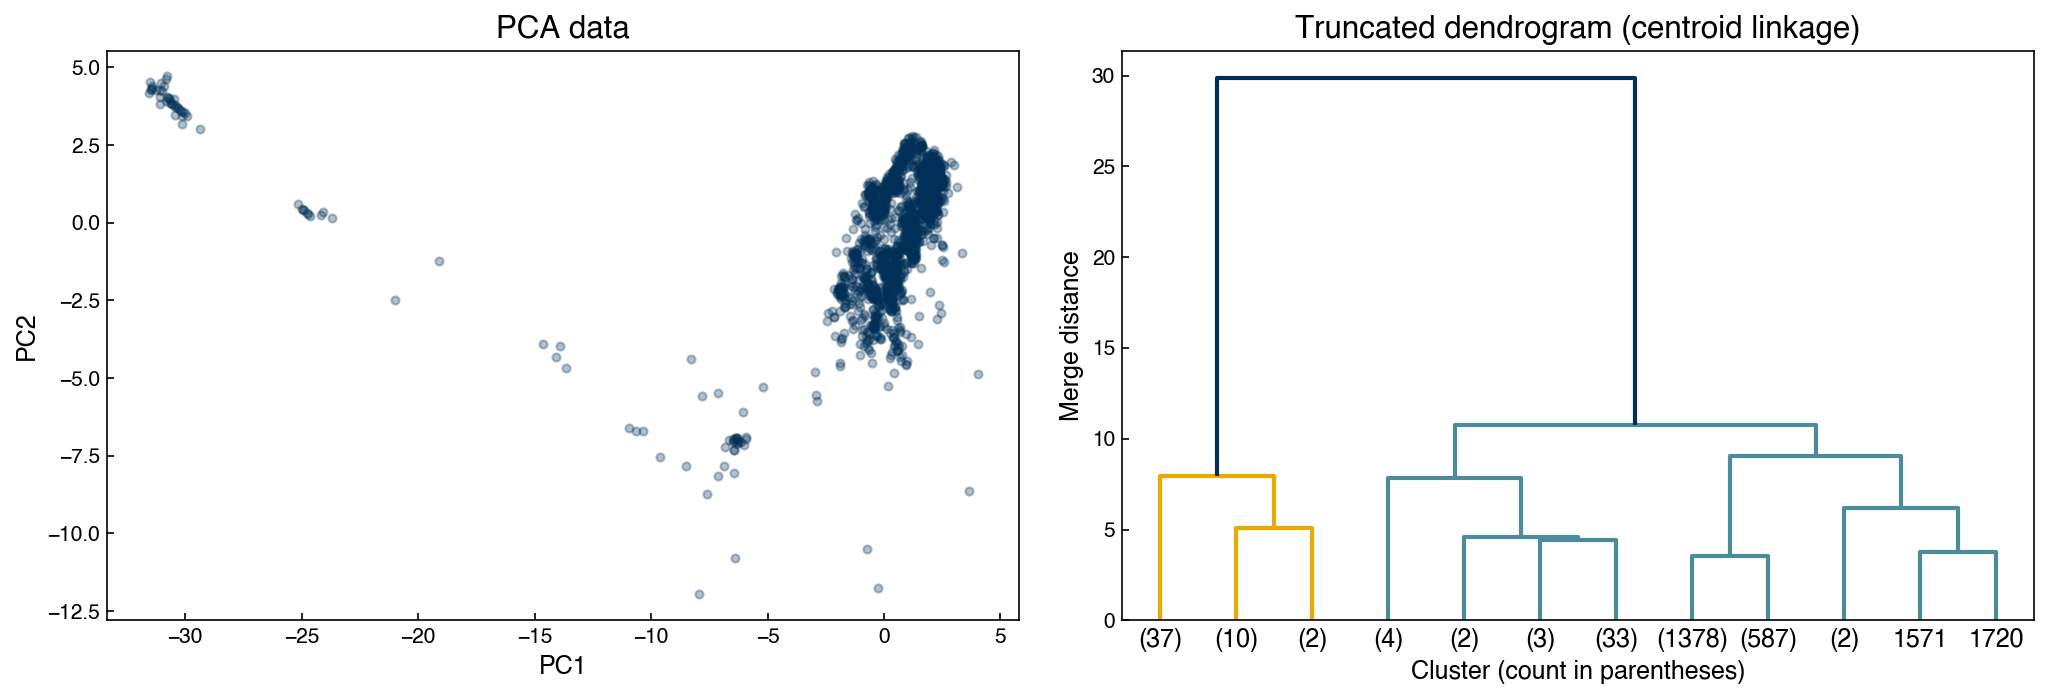

In [20]:
Z = linkage(X_hier, method='centroid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_hier[:, 0], X_hier[:, 1], alpha=0.3, s=15)
axes[0].set_title('PCA data')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
dendrogram(Z, color_threshold=20, truncate_mode='lastp', p=12, ax=axes[1])
axes[1].set_title('Truncated dendrogram (centroid linkage)')
axes[1].set_xlabel('Cluster (count in parentheses)')
axes[1].set_ylabel('Merge distance')
plt.tight_layout()

With 2,060 points and a truncated dendrogram, it is hard to see how an individual point maps onto a dendrogram leaf. The mapping is easiest to grasp on a handful of labeled points: below we sample 15 points, label them in PC space, and show the full (untruncated) dendrogram using the same labels, so each leaf can be traced back to its location.

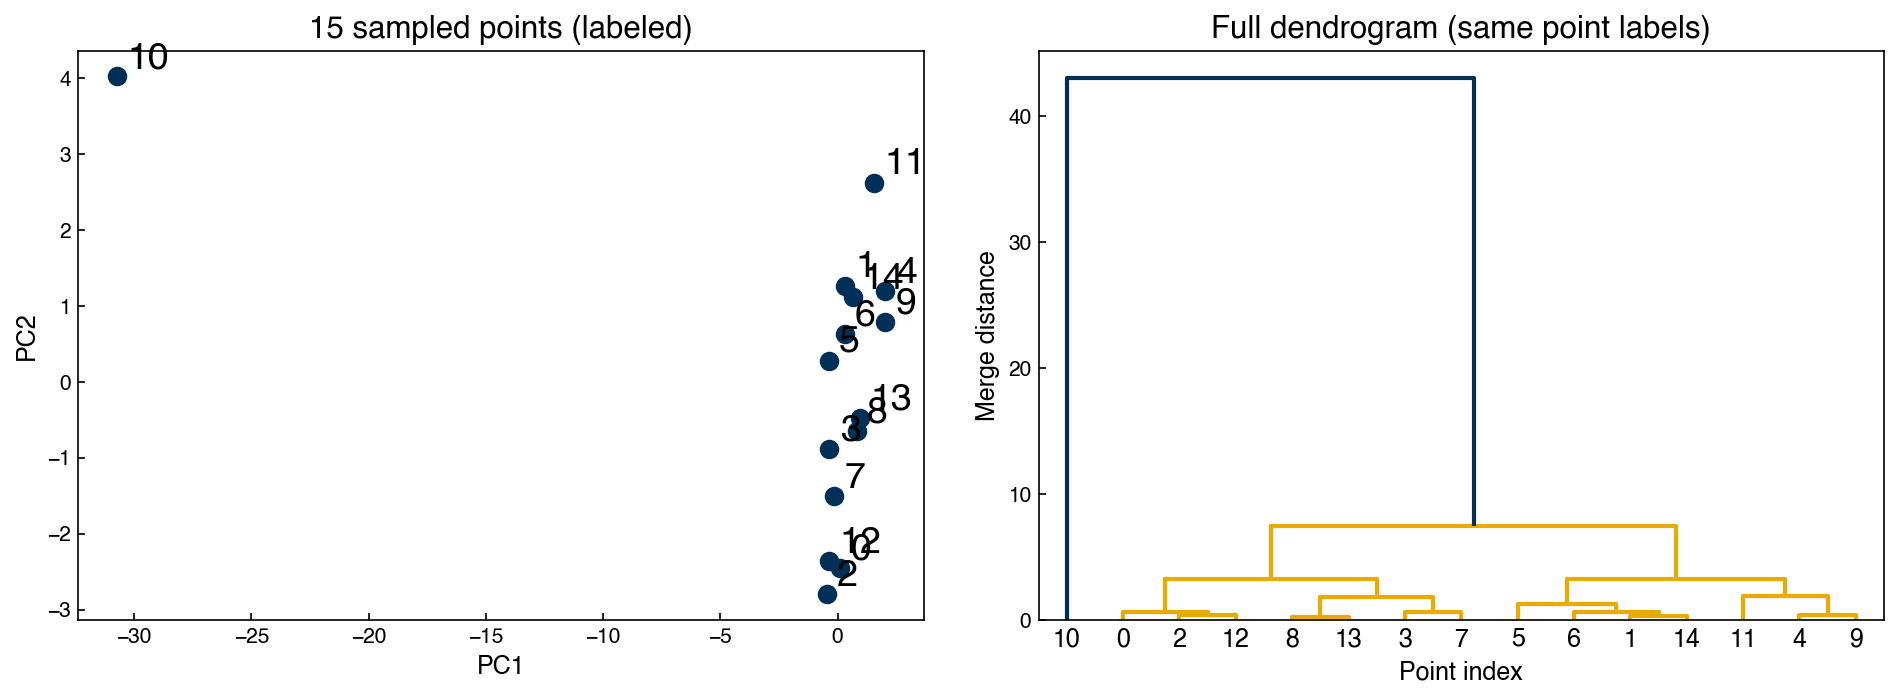

In [21]:
idx     = np.random.default_rng(0).choice(len(X_hier), 15, replace=False)
X_small = X_hier[idx]
Z_small = linkage(X_small, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_small[:, 0], X_small[:, 1], s=70, color=clrs[0], zorder=3)
for i, (px, py) in enumerate(X_small):
    axes[0].annotate(str(i), (px, py), textcoords='offset points', xytext=(5, 4))
axes[0].set_title('15 sampled points (labeled)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

dendrogram(Z_small, labels=[str(i) for i in range(len(X_small))], ax=axes[1])
axes[1].set_title('Full dendrogram (same point labels)')
axes[1].set_xlabel('Point index'); axes[1].set_ylabel('Merge distance')
plt.tight_layout()

Tracing the labels between the two panels makes the correspondence concrete: points that join low in the tree (small merge distance) are near neighbors in the scatter, while points joined only near the top are far apart. The same logic scales to the full dataset — there are simply too many leaves to label individually.

### Agglomerative Clustering

`fcluster` extracts flat clusters from the linkage matrix using either a distance cutoff or an explicit cluster count:

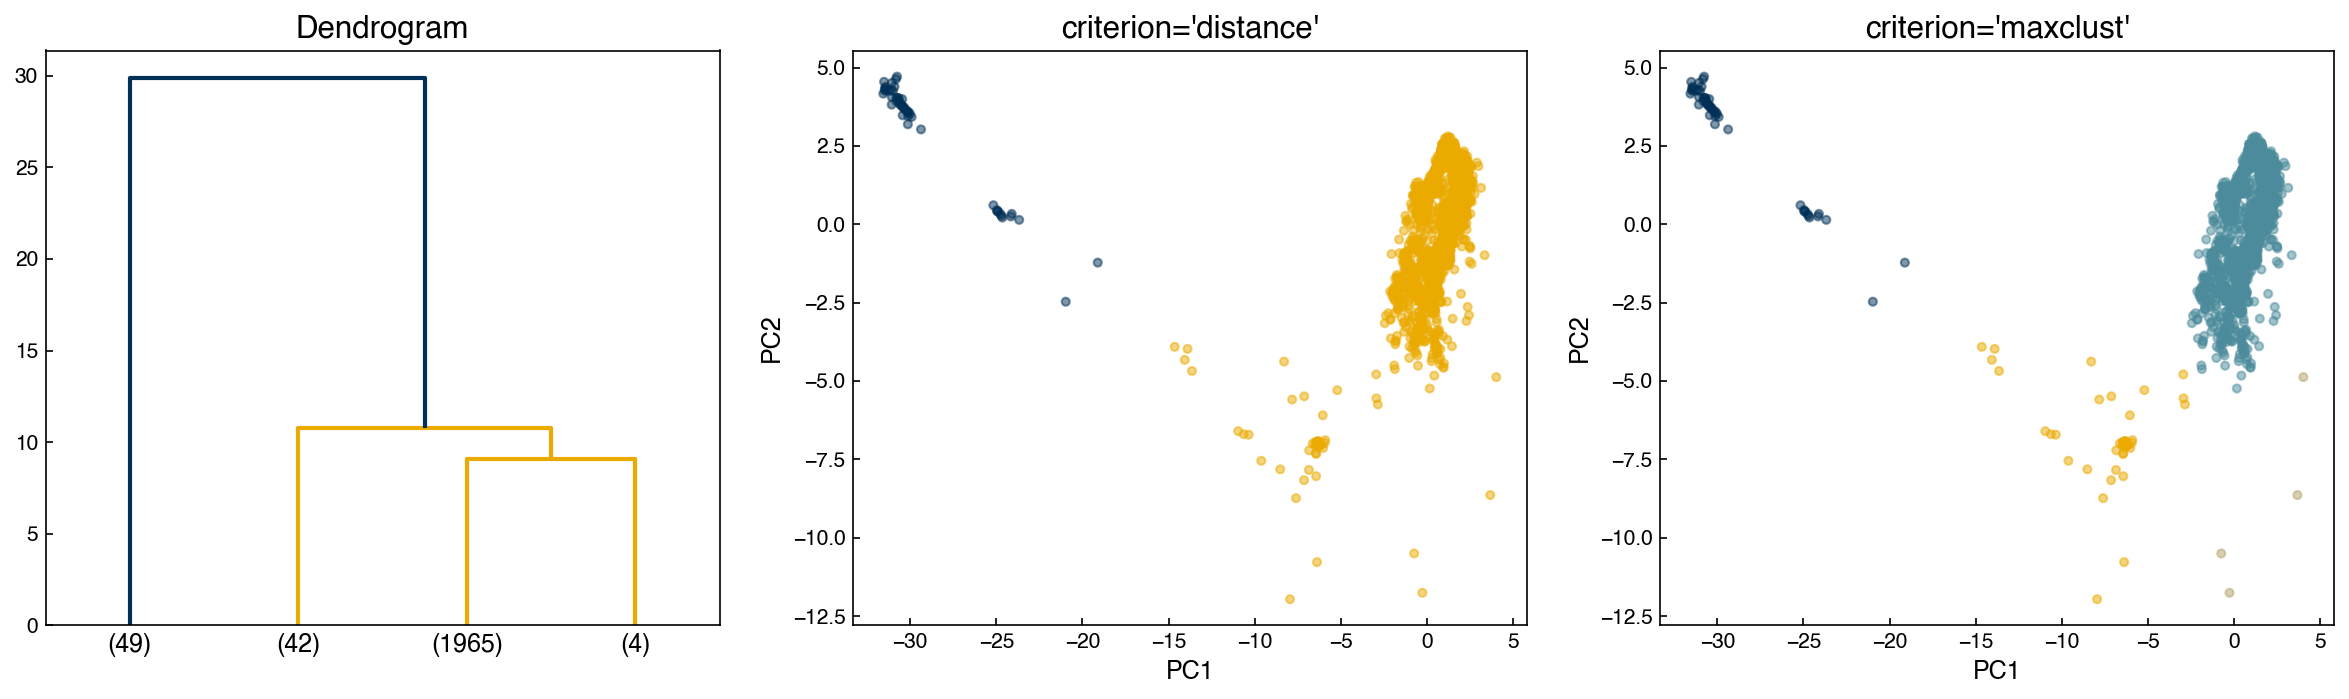

In [22]:
from scipy.cluster.hierarchy import fcluster

max_d         = 20
k             = 4
clusters_dist = fcluster(Z, max_d, criterion='distance')
clusters_k    = fcluster(Z, k,     criterion='maxclust')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dendrogram(Z, color_threshold=max_d, truncate_mode='lastp', p=k, ax=axes[0])
axes[0].set_title('Dendrogram')
for ax, labs, title in zip(axes[1:],
                           [clusters_dist, clusters_k],
                           ["criterion='distance'", "criterion='maxclust'"]):
    ax.scatter(X_hier[:, 0], X_hier[:, 1],
               c=clrs[(labs - 1) % len(clrs)], alpha=0.5, s=15)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

:::{figure} images/agglomerative_animation.gif
:name: fig-agglomerative-anim
:width: 70%

Animation of agglomerative hierarchical clustering. At each step the two closest clusters are merged. The horizontal cut height determines how many final clusters are produced.
:::

An alternative to a manual cutoff is the **inconsistency method**, which detects jumps in merge distances:

$$I = \frac{h - \bar{h}}{\sigma_h}$$

where $h$ is the merge height and $\bar{h}$, $\sigma_h$ are the mean and standard deviation of the last $d$ merges. If $I \geq t$ the merge is treated as a cluster boundary.

Inconsistency method found 5 clusters


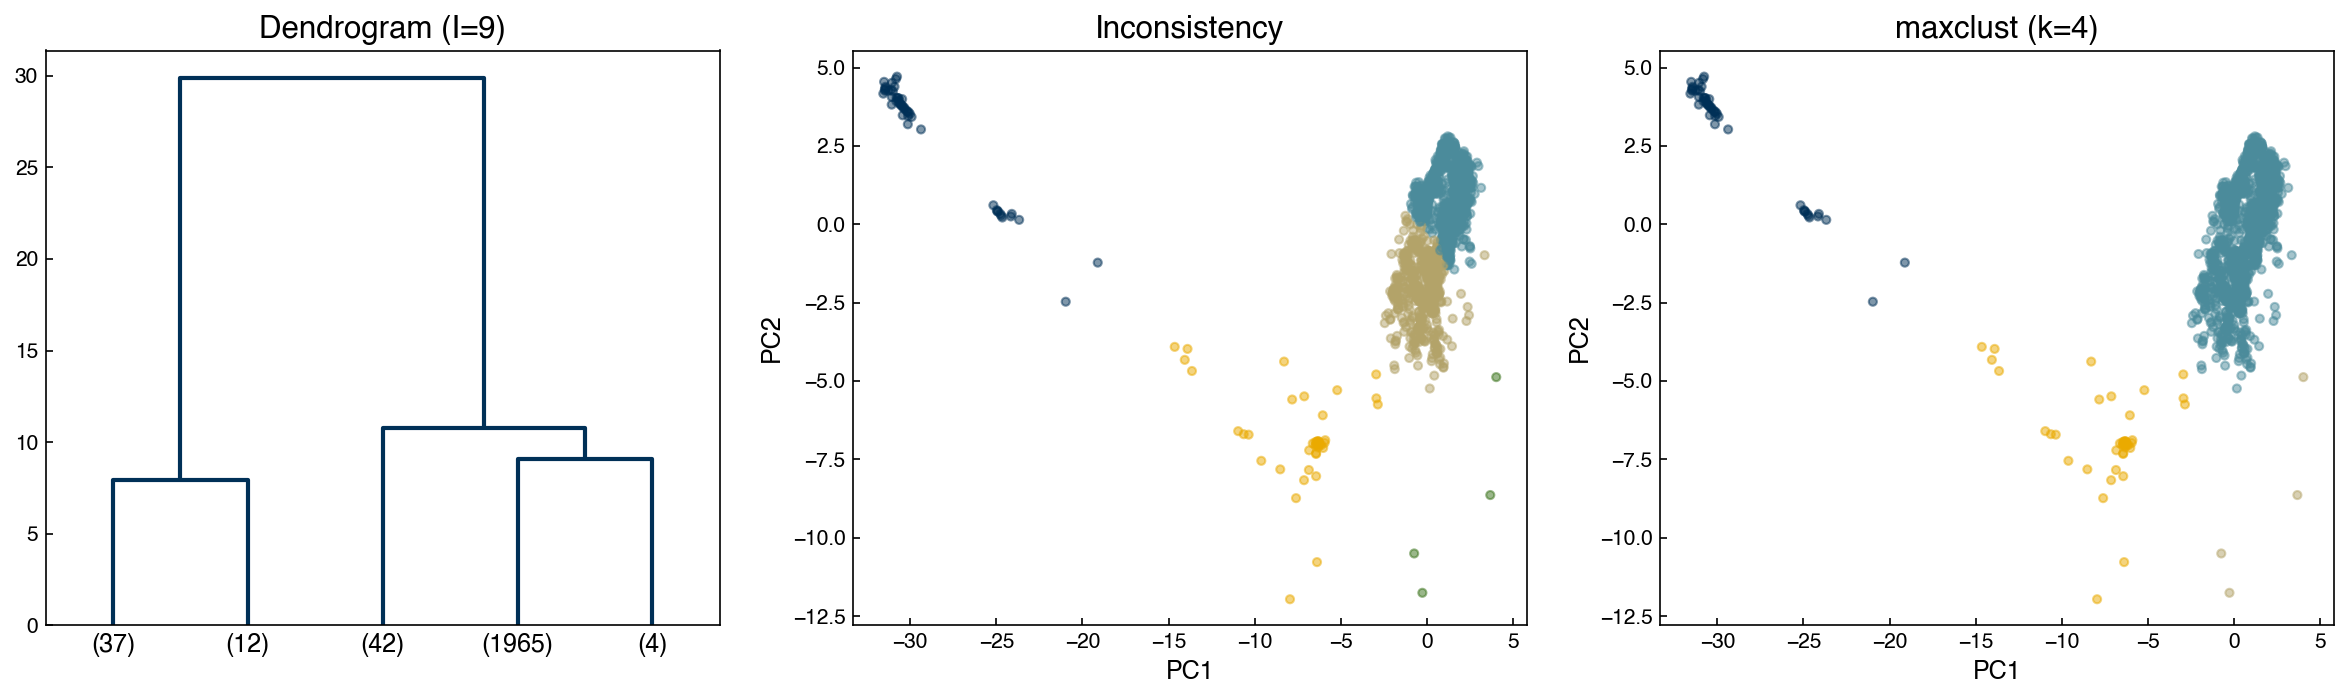

In [23]:
I_cutoff   = 9
clusters_I = fcluster(Z, I_cutoff, criterion='inconsistent', depth=10)
n_found    = clusters_I.max()
print(f'Inconsistency method found {n_found} clusters')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dendrogram(Z, color_threshold=3, truncate_mode='lastp', p=int(n_found), ax=axes[0])
axes[0].set_title(f'Dendrogram (I={I_cutoff})')
for ax, labs, title in zip(axes[1:],
                           [clusters_I, clusters_k],
                           ['Inconsistency', 'maxclust (k=4)']):
    ax.scatter(X_hier[:, 0], X_hier[:, 1],
               c=clrs[(labs - 1) % len(clrs)], alpha=0.5, s=15)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()

:::{note}
Automated cutoff selection (elbow, inconsistency) rarely gives perfect results on real data. The standard practice is to use an automatic criterion as a starting point, then refine the cutoff by inspecting the dendrogram and confirming that the resulting clusters align with domain knowledge.
:::

:::{exercise}
:label: ex-eda-linkage-compare

Fit agglomerative hierarchical clustering models on the PCA-reduced Dow dataset using linkage methods `single`, `complete`, `average`, and `ward`, each extracting `k=4` clusters via `criterion='maxclust'`. Plot the four cluster assignments side-by-side and compute the silhouette score for each method. Which linkage produces the most compact, well-separated clusters?
:::

## Summary

- **Clustering** is unsupervised: it identifies structure in data without labels. The three main families are expectation-maximization (k-means, GMM), density-based (mean shift, DBSCAN), and hierarchical.
- **Silhouette score** ($-1$ to $1$) and **Calinski-Harabász score** measure cluster compactness and separation without labels. **BIC** is available for probability-based models (GMMs) and penalizes model complexity.
- When true labels *are* available, cluster numbering is arbitrary, so accuracy cannot be used directly. **Purity** — the sum of the confusion-matrix column maxima divided by $N$ — assigns each cluster its majority class and is unaffected by relabeling. It rises monotonically with $K$, so it can report on a clustering but cannot be used to choose $K$.
- **k-means** is fast and often effective, but requires $k$ upfront and assumes spherical clusters. Elbow plots and silhouette scores help choose $k$.
- **Gaussian mixture models** extend k-means with flexible covariance shapes and mixed membership probabilities. BIC provides a principled way to select the number of components.
- **Mean shift** infers the number of clusters from the bandwidth parameter. The scikit-learn implementation is efficient and includes a bandwidth estimation utility.
- **DBSCAN** handles arbitrary cluster shapes and explicitly labels noise, but is sensitive to $\varepsilon$ and `min_samples`. It does not natively project new points.
- **Hierarchical clustering** builds a complete linkage tree visualized as a dendrogram. The cophenetic correlation coefficient guides linkage method selection; flat clusters are extracted by a distance or count cutoff.
- Applying dimensionality reduction before clustering enables visualization and often improves results, but cluster interpretations should always be checked against the original feature space.

## Additional Reading

- [scikit-learn Clustering Guide](https://scikit-learn.org/stable/modules/clustering.html) — comprehensive reference and algorithm comparison
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, Chapter 14 — unsupervised learning including clustering and mixture models
- Manning, Raghavan & Schütze, [*Introduction to Information Retrieval*](https://nlp.stanford.edu/IR-book/), Chapter 16 — the standard reference for purity and the other external evaluation measures for clustering